# Benchmark Validation under Low-Resolution Downscaling

This notebook validates the behavior of the benchmark pipeline under controlled input downscaling:

1. Loads representative dataset samples.
2. Applies systematic scale factors ($s \in \{0.5x, 0.75x, 1.0x\}$).
3. Compares original vs degraded resolution inputs and annotation scaling.
4. Validates metric stability under severe pixel degradation.

In [1]:
import os
import sys
from pathlib import Path

# Resolve project root dynamically
project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()),
    Path.cwd().parent
)
PROJECT_ROOT = project_root
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
mmpose_root = project_root / "models" / "mmpose"
if mmpose_root.exists() and str(mmpose_root) not in sys.path:
    sys.path.insert(0, str(mmpose_root))

print(f"Project root: {project_root}")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

from pose_uncertainty.data_loader import COCOLoader
from pose_uncertainty.utils.types import ImageSample

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams['figure.dpi'] = 120

print("Notebook ready for input downscaling evaluation.")

Project root: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta
Notebook listo para probar la reducción de resolución.


# Preprocessing & Coordinate Transformation Validation

Verifies that input resolution reduction correctly scales bounding box coordinates and ground truth keypoint annotations without spatial drift.

In [2]:
dataset_root = project_root / "data" / "coco"
annotation_file = "annotations/person_keypoints_val2017.json"
image_subdir = "val2017"
benchmark_scales = [1.0, 0.75, 0.5, 0.25, 0.2, 0.17, 0.15, 0.125, 0.0625, 0.05, 0.01]

loader_args = {
    "data_root": str(dataset_root),
    "ann_file": annotation_file,
    "image_dir": image_subdir,
}

idx = 10  # Desired sample index

sample_variants = {
    scale: next(itertools.islice(COCOLoader(**loader_args, resize_scale=scale), idx, idx + 1))
    for scale in benchmark_scales
}

sample_full = sample_variants[1.0]

comparison_df = pd.DataFrame(
    [
        {
            "scale": scale,
            "image_width": sample.image_array.shape[1],
            "image_height": sample.image_array.shape[0],
            "bbox_x": round(sample.bbox[0], 2),
            "bbox_y": round(sample.bbox[1], 2),
            "bbox_w": round(sample.bbox[2], 2),
            "bbox_h": round(sample.bbox[3], 2),
        }
        for scale, sample in sample_variants.items()
    ]
).sort_values("scale", ascending=False)

display(comparison_df)
print(f"Base image: {sample_full.image_array.shape}")
print(f"Base BBox: {tuple(round(v, 2) for v in sample_full.bbox)}")

Cargando anotaciones desde c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\data\coco\annotations/person_keypoints_val2017.json...
loading annotations into memory...
Done (t=0.32s)
creating index...
index created!
Dataset cargado: 2693 imágenes encontradas.
Cargando anotaciones desde c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\data\coco\annotations/person_keypoints_val2017.json...
loading annotations into memory...
Done (t=0.21s)
creating index...
index created!
Dataset cargado: 2693 imágenes encontradas.
Cargando anotaciones desde c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\data\coco\annotations/person_keypoints_val2017.json...
loading annotations into memory...
Done (t=0.25s)
creating index...
index created!
Dataset cargado: 2693 imágenes encontradas.
Cargando anotaciones desde c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\data\coco\annotations/person_keypoints_val2017.json...
loading annotations into me

,scale,image_width,image_height,bbox_x,bbox_y,bbox_w,bbox_h
0,1.0000,640,480,244.78,10.44,171.68,459.50
1,0.7500,480,360,183.59,7.83,128.76,344.62
2,0.5000,320,240,122.39,5.22,85.84,229.75
3,0.2500,160,120,61.20,2.61,42.92,114.88
4,0.2000,128,96,48.96,2.09,34.34,91.90
5,0.1700,109,82,41.61,1.77,29.19,78.12
6,0.1500,96,72,36.72,1.57,25.75,68.92
7,0.1250,80,60,30.60,1.30,21.46,57.44
8,0.0625,40,30,15.30,0.65,10.73,28.72
9,0.0500,32,24,12.24,0.52,8.58,22.98


Imagen base: (480, 640, 3)
BBox base: (244.78, 10.44, 171.68, 459.5)


In [3]:
def resize_image_and_annotations(image, bbox, keypoints, scale):
    """Resize an image and scale bbox/keypoints with the same factor."""
    if scale is None or abs(scale - 1.0) < 1e-8:
        return image, bbox, keypoints

    if scale <= 0:
        raise ValueError(f"scale must be > 0, got {scale}")

    height, width = image.shape[:2]
    new_width = max(1, int(round(width * scale)))
    new_height = max(1, int(round(height * scale)))
    interpolation = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_LINEAR
    resized = cv2.resize(image, (new_width, new_height), interpolation=interpolation)

    x, y, w, h = bbox
    resized_bbox = (x * scale, y * scale, w * scale, h * scale)

    resized_keypoints = []
    for kp in keypoints:
        resized_keypoints.append(
            type(kp)(
                id=kp.id,
                x=kp.x * scale,
                y=kp.y * scale,
                confidence=kp.confidence,
                name=kp.name,
            )
        )

    return resized, resized_bbox, resized_keypoints


def build_scaled_sample(sample, scale):
    image, bbox, keypoints = resize_image_and_annotations(
        sample.image_array,
        sample.bbox,
        sample.ground_truth_keypoints or [],
        scale,
    )
    return ImageSample(
        image_id=sample.image_id,
        image_path=sample.image_path,
        image_array=image,
        bbox=bbox,
        ground_truth_keypoints=keypoints,
        dataset_source=sample.dataset_source,
    )


def draw_pose_sample(ax, image, bbox, keypoints, title):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

    x, y, w, h = bbox
    ax.add_patch(
        plt.Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            edgecolor="cyan",
            linewidth=2,
        )
    )

    for kp in keypoints:
        ax.scatter(kp.x, kp.y, s=18, c="yellow", edgecolors="black", linewidths=0.4)
        ax.text(kp.x + 1.5, kp.y + 1.5, kp.name, fontsize=6, color="white")

# Original vs Downscaled Input Comparison

Demonstrates the impact of `dataset.resize_scale` on input image quality, validating that global scene structure is preserved while high-frequency textures are degraded.

scale=1.0: loader shape=(480, 640, 3), manual shape=(480, 640, 3), bbox_loader=(244.78, 10.44, 171.68, 459.5), bbox_manual=(244.78, 10.44, 171.68, 459.5)
scale=0.75: loader shape=(360, 480, 3), manual shape=(360, 480, 3), bbox_loader=(183.59, 7.83, 128.76, 344.62), bbox_manual=(183.59, 7.83, 128.76, 344.62)
scale=0.5: loader shape=(240, 320, 3), manual shape=(240, 320, 3), bbox_loader=(122.39, 5.22, 85.84, 229.75), bbox_manual=(122.39, 5.22, 85.84, 229.75)
scale=0.25: loader shape=(120, 160, 3), manual shape=(120, 160, 3), bbox_loader=(61.2, 2.61, 42.92, 114.88), bbox_manual=(61.2, 2.61, 42.92, 114.88)
scale=0.2: loader shape=(96, 128, 3), manual shape=(96, 128, 3), bbox_loader=(48.96, 2.09, 34.34, 91.9), bbox_manual=(48.96, 2.09, 34.34, 91.9)
scale=0.17: loader shape=(82, 109, 3), manual shape=(82, 109, 3), bbox_loader=(41.61, 1.77, 29.19, 78.12), bbox_manual=(41.61, 1.77, 29.19, 78.12)
scale=0.15: loader shape=(72, 96, 3), manual shape=(72, 96, 3), bbox_loader=(36.72, 1.57, 25.75, 68

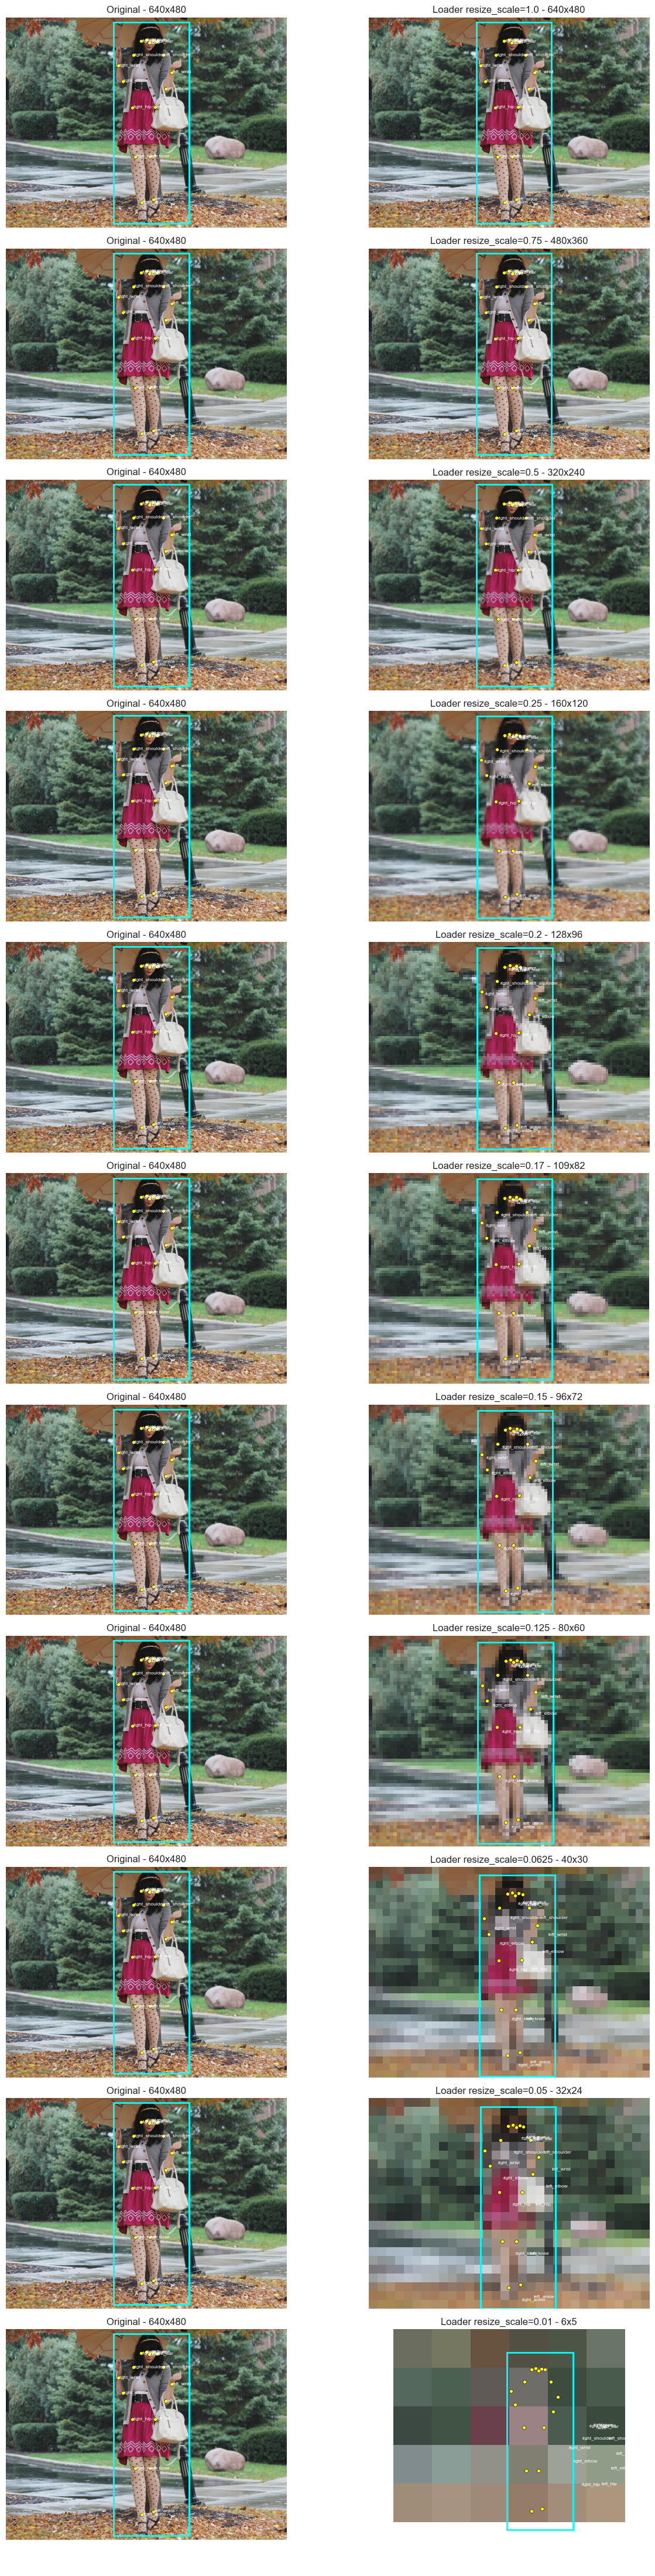

In [4]:
fig, axes = plt.subplots(len(benchmark_scales), 2, figsize=(14, 4 * len(benchmark_scales)))
if len(benchmark_scales) == 1:
    axes = np.array([axes])

for row, scale in enumerate(benchmark_scales):
    resized_sample = sample_variants[scale]
    manual_sample = build_scaled_sample(sample_full, scale)

    draw_pose_sample(
        axes[row, 0],
        sample_full.image_array,
        sample_full.bbox,
        sample_full.ground_truth_keypoints or [],
        f"Original - {sample_full.image_array.shape[1]}x{sample_full.image_array.shape[0]}",
    )
    draw_pose_sample(
        axes[row, 1],
        resized_sample.image_array,
        resized_sample.bbox,
        resized_sample.ground_truth_keypoints or [],
        f"Loader resize_scale={scale} - {resized_sample.image_array.shape[1]}x{resized_sample.image_array.shape[0]}",
    )

    print(
        f"scale={scale}: loader shape={resized_sample.image_array.shape}, manual shape={manual_sample.image_array.shape}, "
        f"bbox_loader={tuple(round(v, 2) for v in resized_sample.bbox)}, bbox_manual={tuple(round(v, 2) for v in manual_sample.bbox)}"
    )

plt.tight_layout()
plt.show()

In [12]:
benchmark_scales = [1.0, 0.75, 0.5, 0.25]
benchmark_commands = [
    f"python src/experiments/benchmarks/run_benchmark.py dataset.resize_scale={scale} force_rerun=true"
    for scale in benchmark_scales
]

print("Recommended CLI Benchmark Commands:")
for command in benchmark_commands:
    print("  ", command)

RUN_MINI_BENCHMARK = False

if RUN_MINI_BENCHMARK:
    try:
        from hydra import compose, initialize_config_dir
        from pose_uncertainty.evaluation.runner import EvaluationRunner

        configs_abs = (project_root / "configs").resolve()
        with initialize_config_dir(config_dir=str(configs_abs), version_base="1.2"):
            cfg = compose(config_name="config", overrides=[
                f"paths.project_root={project_root.as_posix()}",
                "evaluation.debug_limit=1"
            ])
            cfg.dataset.resize_scale = 1.0
            runner = EvaluationRunner(cfg)

        rows = []
        for scale in benchmark_scales:
            scaled_sample = build_scaled_sample(sample_full, scale)
            metrics = runner._evaluate_single(scaled_sample)
            if metrics is None:
                continue
            rows.append({
                "scale": scale,
                "image_width": scaled_sample.image_array.shape[1],
                "image_height": scaled_sample.image_array.shape[0],
                "bbox": scaled_sample.bbox,
                "oks_base": metrics.get("oks_base"),
                "oks_tta": metrics.get("oks_tta"),
                "oks_ours": metrics.get("oks_ours"),
                "delta_oks": metrics.get("delta_oks"),
                "swaps_base": metrics.get("swaps_base"),
                "swaps_ours": metrics.get("swaps_ours"),
                "nll": metrics.get("nll"),
                "entropy": metrics.get("entropy"),
            })

        benchmark_df = pd.DataFrame(rows)
        display(benchmark_df)
    except Exception as exc:
        print(f"Could not execute mini-benchmark: {exc}")
else:
    print("Set RUN_MINI_BENCHMARK = True to execute an interactive single-sample evaluation across resolutions.")

Comandos de benchmark sugeridos:
   python src/experiments/run_benchmark.py dataset.resize_scale=1.0 force_rerun=true
   python src/experiments/run_benchmark.py dataset.resize_scale=0.75 force_rerun=true
   python src/experiments/run_benchmark.py dataset.resize_scale=0.5 force_rerun=true
   python src/experiments/run_benchmark.py dataset.resize_scale=0.25 force_rerun=true
Pon RUN_MINI_BENCHMARK = True para ejecutar una evaluación rápida de una sola imagen por escala.


In [ ]:
'''
output_dir = project_root / "outputs" / "notebooks" / "downscale_validation"
output_dir.mkdir(parents=True, exist_ok=True)

if "comparison_df" in globals():
    comparison_df.to_csv(output_dir / "scale_comparison.csv", index=False)
    print(f"Table saved to: {output_dir / 'scale_comparison.csv'}")

if "benchmark_df" in globals():
    benchmark_df.to_csv(output_dir / "mini_benchmark_metrics.csv", index=False)
    print(f"Metrics saved to: {output_dir / 'mini_benchmark_metrics.csv'}")

if "fig" in globals():
    fig.savefig(output_dir / "scale_comparison.png", dpi=180, bbox_inches="tight")
    print(f"Figure saved to: {output_dir / 'scale_comparison.png'}")

print(f"Output directory ready: {output_dir}")
'''

Tabla guardada en: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\outputs\notebooks\downscale_validation\scale_comparison.csv
Figura guardada en: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\outputs\notebooks\downscale_validation\scale_comparison.png
Directorio de salida listo: c:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta\outputs\notebooks\downscale_validation


# Artifact Persistence & Benchmark Execution Commands

Validation artifacts are saved to `outputs/notebooks/downscale_validation/`.

To execute the full benchmark under specific resolution degradation, use Hydra command line overrides:

```bash
python src/experiments/run_benchmark.py dataset.resize_scale=0.5 force_rerun=true
```